# NYC Taxi Trip Data - Comprehensive Exploratory Data Analysis

**Goal:** Perform a thorough exploration of the yellow taxi trip data from January 2025

This notebook combines exploratory data analysis from multiple team members to provide a comprehensive understanding of the dataset. We'll explore:
- Data structure and quality
- Time patterns (when do people take taxis?)
- Trip characteristics (distance, duration)
- Location patterns (where do people get picked up and dropped off?)
- Payment and tipping behavior
- Relationships between different variables
- Cost breakdown analysis

## 1. Setup and Data Loading

First, we'll import all necessary libraries and load the data.

In [1]:
# ============================================
# IMPORTING LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("✅ Display settings configured!")

✅ All libraries imported successfully!
✅ Display settings configured!


### Loading the Data

Let's load the yellow taxi trip data from January 2025.

In [2]:
# Load the parquet file
file_path = "../../data/raw/yellow_tripdata_2025-01.parquet"
print(f"📂 Loading data from: {file_path}")

df = pd.read_parquet(file_path)

print("✅ Data loaded successfully!")
print(f"✅ Loaded {len(df):,} taxi trips")
print(f"📅 Date range: {df['tpep_pickup_datetime'].min()} to {df['tpep_dropoff_datetime'].max()}")

📂 Loading data from: ../../data/raw/yellow_tripdata_2025-01.parquet
✅ Data loaded successfully!
✅ Loaded 3,475,226 taxi trips
📅 Date range: 2024-12-31 20:47:55 to 2025-02-01 23:44:11


## 2. Initial Data Inspection

Let's get a first look at the data to understand its structure.

In [3]:
# Display first 5 rows
print("=" * 60)
print("FIRST 5 ROWS OF DATA")
print("=" * 60)
df.head()

FIRST 5 ROWS OF DATA


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.00,1.60,1.00,N,229,237,1,10.00,3.50,0.50,3.00,0.00,1.00,18.00,2.50,0.00,0.00
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.00,0.50,1.00,N,236,237,1,5.10,3.50,0.50,2.02,0.00,1.00,12.12,2.50,0.00,0.00
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.00,0.60,1.00,N,141,141,1,5.10,3.50,0.50,2.00,0.00,1.00,12.10,2.50,0.00,0.00
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.00,0.52,1.00,N,244,244,2,7.20,1.00,0.50,0.00,0.00,1.00,9.70,0.00,0.00,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.00,0.66,1.00,N,244,116,2,5.80,1.00,0.50,0.00,0.00,1.00,8.30,0.00,0.00,0.00


In [2]:
print(df.info())

NameError: name 'df' is not defined

In [4]:
# Dataset shape
rows, columns = df.shape
print(f"📊 Dataset Shape:")
print(f"   Rows (trips): {rows:,}")
print(f"   Columns (features): {columns}")
print(f"\n💡 This means:")
print(f"   - We have {rows:,} taxi trips")
print(f"   - Each trip has {columns} pieces of information")

📊 Dataset Shape:
   Rows (trips): 3,475,226
   Columns (features): 20

💡 This means:
   - We have 3,475,226 taxi trips
   - Each trip has 20 pieces of information


## 3. Missing Values Analysis

Missing data can affect our analysis, so let's identify which columns have missing values and how many.

In [7]:
# Missing values analysis
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

# Count missing values in each column
missing_counts = df.isnull().sum()

# Calculate percentage missing
missing_percent = (missing_counts / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_percent
})

# Only show columns that have missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

# Sort by highest missing count first
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary)
else:
    print("✅ EXCELLENT! No missing values in any column!")
    
print(f"\nTotal missing values: {missing_counts.sum():,}")

MISSING VALUES ANALYSIS
Columns with missing values:
                      Missing_Count  Percentage
passenger_count              540149       15.54
RatecodeID                   540149       15.54
store_and_fwd_flag           540149       15.54
congestion_surcharge         540149       15.54
Airport_fee                  540149       15.54

Total missing values: 2,700,745


## 4. Statistical Summary

Let's look at the basic statistics for all numerical columns to understand the distribution of our data.

In [8]:
# Statistical summary of numerical columns
print("=" * 70)
print("STATISTICAL SUMMARY OF NUMERICAL COLUMNS")
print("=" * 70)
df.describe()

STATISTICAL SUMMARY OF NUMERICAL COLUMNS


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3475226.00,3475226,3475226,2935077.00,3475226.00,2935077.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,2935077.00,2935077.00,3475226.00
mean,1.79,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.30,5.86,2.48,165.19,164.13,1.04,17.08,1.32,0.48,2.96,0.45,0.95,25.61,2.23,0.12,0.48
min,1.00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.00,0.00,1.00,1.00,1.00,0.00,-900.00,-7.50,-0.50,-86.00,-126.94,-1.00,-901.00,-2.50,-1.75,-0.75
25%,2.00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.00,0.98,1.00,132.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.20,2.50,0.00,0.00
50%,2.00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.00,1.67,1.00,162.00,162.00,1.00,12.11,0.00,0.50,2.45,0.00,1.00,19.95,2.50,0.00,0.75
75%,2.00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.00,3.10,1.00,234.00,234.00,1.00,19.50,2.50,0.50,3.93,0.00,1.00,27.78,2.50,0.00,0.75
max,7.00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.00,276423.57,99.00,265.00,265.00,5.00,863372.12,15.00,10.50,400.00,170.94,1.00,863380.37,2.50,6.75,0.75
std,0.43,NaN,NaN,0.75,564.60,11.63,64.53,69.40,0.70,463.47,1.86,0.14,3.78,2.00,0.28,463.66,0.90,0.47,0.36


## 5. Data Quality Checks

Let's identify potential data quality issues like negative values, zero passengers, or extreme outliers that might indicate data errors.

In [9]:
# Data quality checks
print("=" * 70)
print("POTENTIAL DATA QUALITY ISSUES")
print("=" * 70)

# Check for negative values (impossible!)
print("\n1. NEGATIVE VALUES CHECK:")
print("-" * 50)

if 'trip_distance' in df.columns:
    negative_distance = len(df[df['trip_distance'] < 0])
    print(f"   Trips with negative distance: {negative_distance:,}")
    
if 'fare_amount' in df.columns:
    negative_fare = len(df[df['fare_amount'] < 0])
    print(f"   Trips with negative fare: {negative_fare:,}")

if 'passenger_count' in df.columns:
    zero_passengers = len(df[df['passenger_count'] == 0])
    print(f"   Trips with 0 passengers: {zero_passengers:,}")
    
    max_passengers = df['passenger_count'].max()
    print(f"   Maximum passengers in a trip: {max_passengers}")

# Check for extreme values
print("\n2. EXTREME VALUES CHECK:")
print("-" * 50)

if 'trip_distance' in df.columns:
    long_trips = len(df[df['trip_distance'] > 100])
    print(f"   Trips over 100 miles: {long_trips:,}")
    
if 'fare_amount' in df.columns:
    expensive_trips = len(df[df['fare_amount'] > 500])
    print(f"   Trips over $500: {expensive_trips:,}")

POTENTIAL DATA QUALITY ISSUES

1. NEGATIVE VALUES CHECK:
--------------------------------------------------
   Trips with negative distance: 0
   Trips with negative fare: 144,118
   Trips with 0 passengers: 24,656
   Maximum passengers in a trip: 9.0

2. EXTREME VALUES CHECK:
--------------------------------------------------
   Trips over 100 miles: 162
   Trips over $500: 55


## 6. Passenger Count Analysis

How many passengers typically ride in taxis? This helps us understand usage patterns.

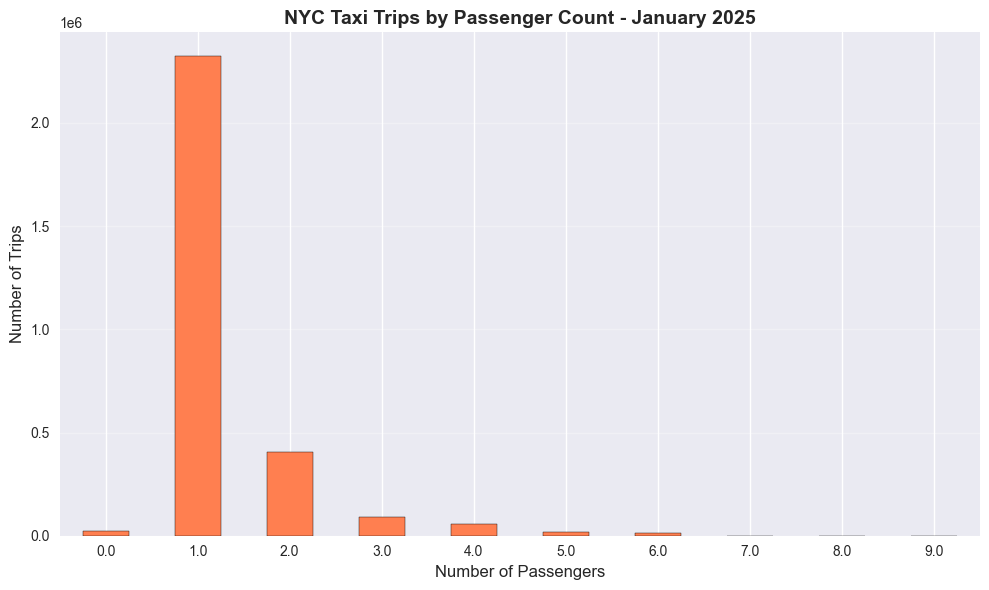


Trips by passenger count:
passenger_count
0.00      24656
1.00    2322434
2.00     407761
3.00      91409
4.00      59009
5.00      17786
6.00      12004
7.00          4
8.00         11
9.00          3
Name: count, dtype: int64


In [11]:
# Passenger count analysis
plt.figure(figsize=(10, 6))

# Count how many trips for each passenger count
passenger_counts = df['passenger_count'].value_counts().sort_index()

# Create bar chart
passenger_counts.plot(kind='bar', 
                      color='coral', 
                      edgecolor='black')

plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('NYC Taxi Trips by Passenger Count - January 2025', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=0)  # Keep numbers horizontal
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show the actual numbers
print("\nTrips by passenger count:")
print(passenger_counts)

## 7. Time Patterns Analysis

Understanding when people take taxis helps identify peak hours and day-of-week patterns. This is crucial for resource allocation and demand forecasting.

In [12]:
# Extract time features from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

### 7.1 Trips by Hour of Day

Let's see which hours of the day are busiest for taxi rides.

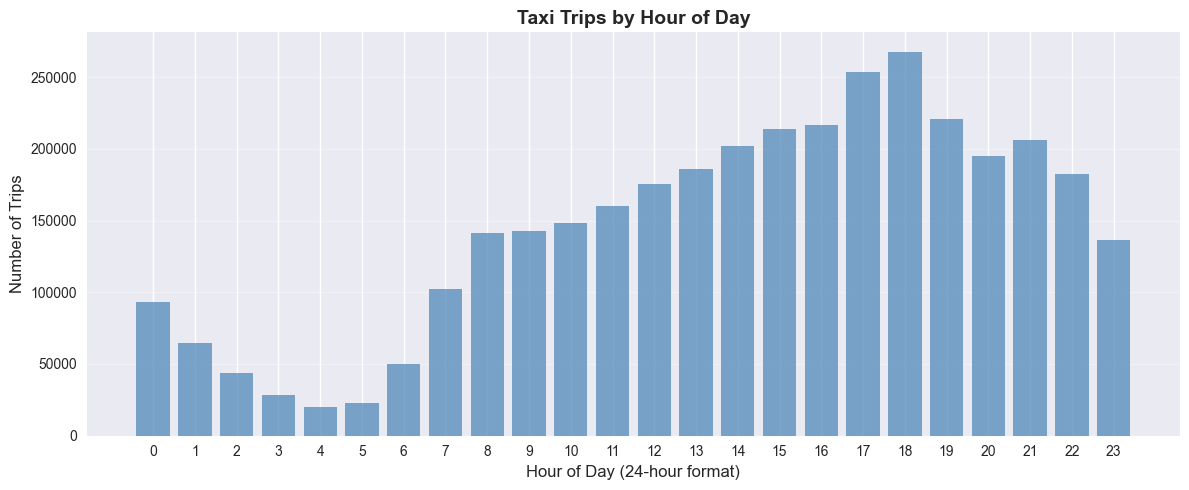


Peak Hours:
Hour 18:00 - 267,951 trips
Hour 17:00 - 253,518 trips
Hour 19:00 - 221,055 trips


In [13]:
# Count trips by hour of day
trips_by_hour = df['pickup_hour'].value_counts().sort_index()

# Create visualization
plt.figure(figsize=(12, 5))
plt.bar(trips_by_hour.index, trips_by_hour.values, color='steelblue', alpha=0.7)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Taxi Trips by Hour of Day', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# Print peak hours
peak_hours = trips_by_hour.nlargest(3)
print("\nPeak Hours:")
print("=" * 40)
for hour, count in peak_hours.items():
    print(f"Hour {hour:02d}:00 - {count:,} trips")

### 7.2 Trips by Day of Week

Let's see how taxi usage varies across different days of the week.

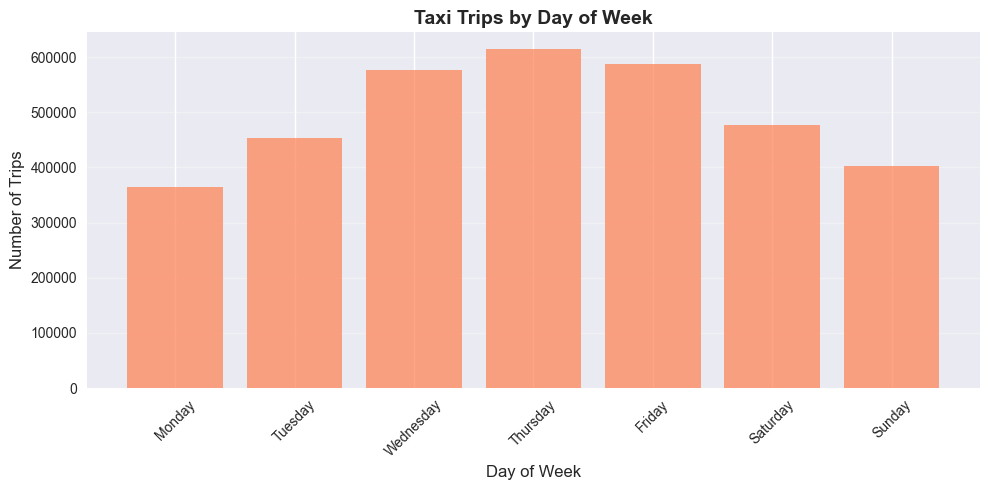


Trips by Day of Week:
Monday      : 363,772 trips
Tuesday     : 453,993 trips
Wednesday   : 577,375 trips
Thursday    : 614,230 trips
Friday      : 586,863 trips
Saturday    : 476,399 trips
Sunday      : 402,594 trips


In [14]:
# Count trips by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trips_by_day = df['pickup_day_of_week'].value_counts().reindex(day_order)

# Create visualization
plt.figure(figsize=(10, 5))
plt.bar(trips_by_day.index, trips_by_day.values, color='coral', alpha=0.7)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Taxi Trips by Day of Week', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\nTrips by Day of Week:")
print("=" * 40)
for day, count in trips_by_day.items():
    print(f"{day:12s}: {count:,} trips")

## 8. Trip Duration Analysis

Trip duration tells us how long passengers spend in taxis. This is calculated as the difference between pickup and dropoff times.

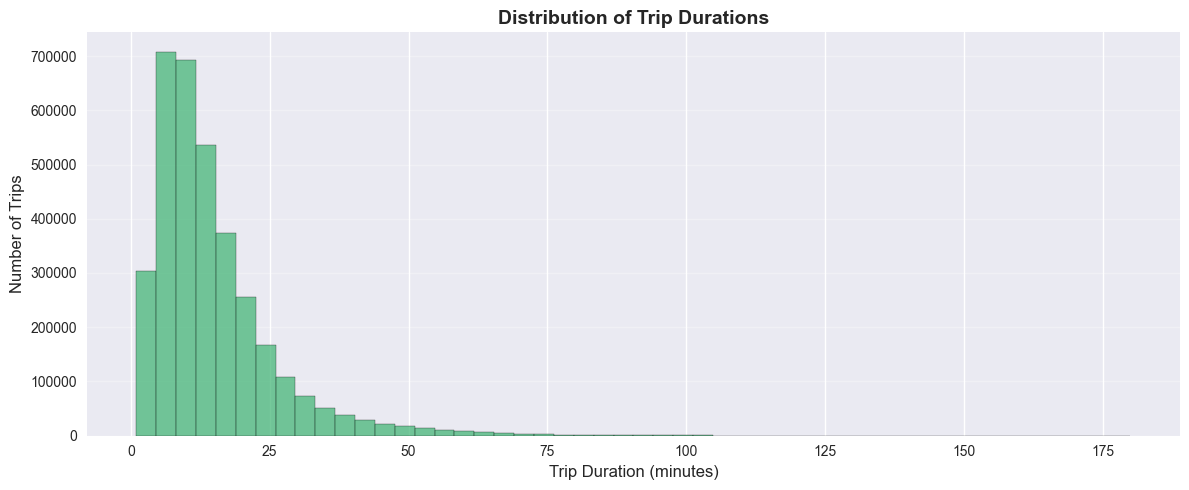


Trip Duration Statistics:
Mean duration:   14.75 minutes
Median duration: 11.82 minutes
Min duration:    1.00 minutes
Max duration:    179.97 minutes

Most common duration range: 9 minutes


In [15]:
# Calculate trip duration in minutes
df['trip_duration_minutes'] = (
    (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
)

# Remove any unrealistic durations (negative or extremely long trips)
# Filter trips between 1 minute and 3 hours (180 minutes)
valid_durations = df[
    (df['trip_duration_minutes'] >= 1) & 
    (df['trip_duration_minutes'] <= 180)
]['trip_duration_minutes']

# Create histogram
plt.figure(figsize=(12, 5))
plt.hist(valid_durations, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='black')
plt.xlabel('Trip Duration (minutes)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Distribution of Trip Durations', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("\nTrip Duration Statistics:")
print("=" * 40)
print(f"Mean duration:   {valid_durations.mean():.2f} minutes")
print(f"Median duration: {valid_durations.median():.2f} minutes")
print(f"Min duration:    {valid_durations.min():.2f} minutes")
print(f"Max duration:    {valid_durations.max():.2f} minutes")
print(f"\nMost common duration range: {valid_durations.mode().values[0]:.0f} minutes")

## 9. Location Analysis

Let's see which locations are the most popular for pickups and dropoffs. This helps understand where taxi demand is highest.

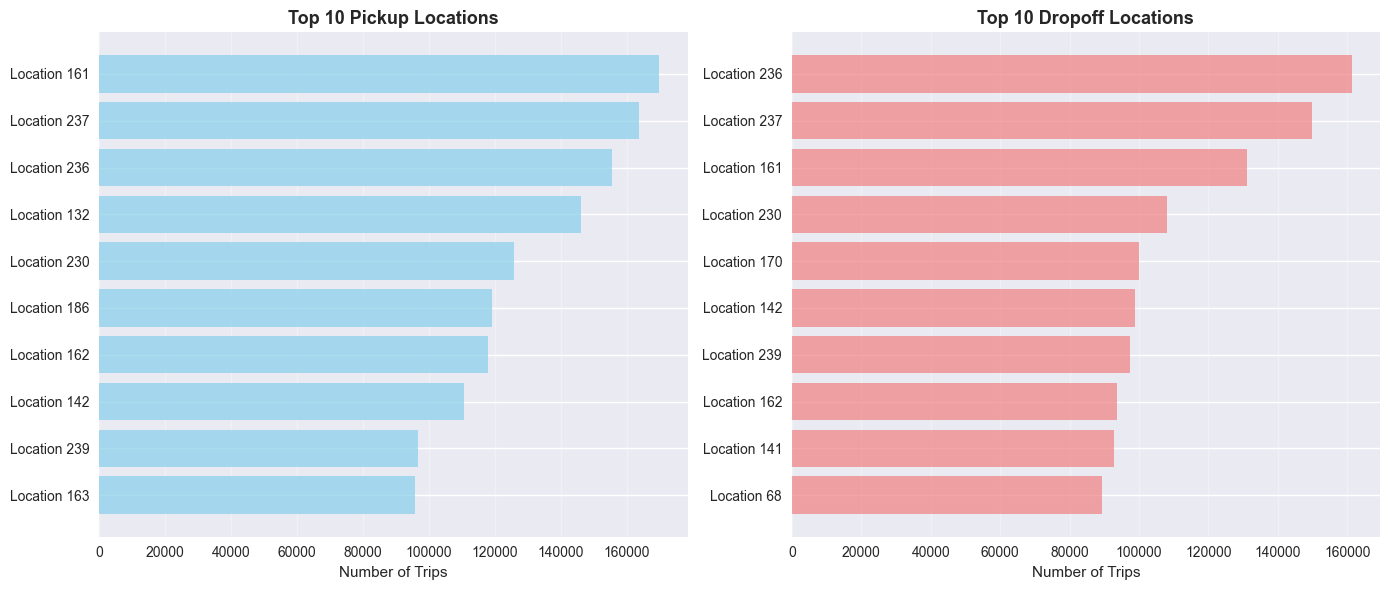


Top 5 Pickup Locations:
Location 161: 169,977 trips
Location 237: 163,703 trips
Location 236: 155,647 trips
Location 132: 146,137 trips
Location 230: 125,829 trips

Top 5 Dropoff Locations:
Location 236: 161,376 trips
Location 237: 149,970 trips
Location 161: 131,258 trips
Location 230: 108,177 trips
Location 170: 100,060 trips


In [16]:
# Find top 10 pickup locations
top_pickup_locations = df['PULocationID'].value_counts().head(10)

# Find top 10 dropoff locations
top_dropoff_locations = df['DOLocationID'].value_counts().head(10)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pickup locations
axes[0].barh(range(len(top_pickup_locations)), top_pickup_locations.values, color='skyblue', alpha=0.7)
axes[0].set_yticks(range(len(top_pickup_locations)))
axes[0].set_yticklabels([f"Location {loc}" for loc in top_pickup_locations.index])
axes[0].set_xlabel('Number of Trips', fontsize=11)
axes[0].set_title('Top 10 Pickup Locations', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Dropoff locations
axes[1].barh(range(len(top_dropoff_locations)), top_dropoff_locations.values, color='lightcoral', alpha=0.7)
axes[1].set_yticks(range(len(top_dropoff_locations)))
axes[1].set_yticklabels([f"Location {loc}" for loc in top_dropoff_locations.index])
axes[1].set_xlabel('Number of Trips', fontsize=11)
axes[1].set_title('Top 10 Dropoff Locations', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Print top locations
print("\nTop 5 Pickup Locations:")
print("=" * 40)
for loc, count in top_pickup_locations.head(5).items():
    print(f"Location {loc:3d}: {count:,} trips")

print("\nTop 5 Dropoff Locations:")
print("=" * 40)
for loc, count in top_dropoff_locations.head(5).items():
    print(f"Location {loc:3d}: {count:,} trips")

### 10.1 Pickup to Dropoff Flow Heatmap

This heatmap shows the most common routes (pickup location to dropoff location) in the dataset.

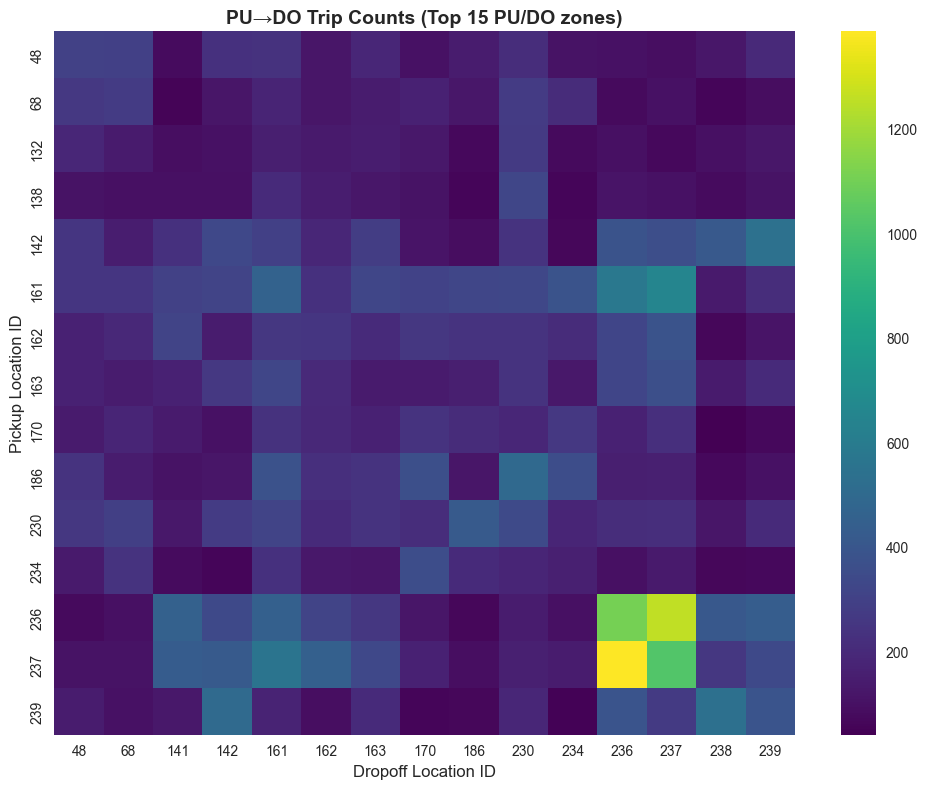

In [17]:
# Create a sample for faster computation
sample_size = min(200000, len(df))
plot_df = df.sample(n=sample_size, random_state=42)

# Top pickup and dropoff locations
top_n = 15
top_pu = plot_df['PULocationID'].value_counts().head(top_n).index
top_do = plot_df['DOLocationID'].value_counts().head(top_n).index

# Create matrix of pickup to dropoff trips
mat = (plot_df[plot_df['PULocationID'].isin(top_pu) & plot_df['DOLocationID'].isin(top_do)]
       .groupby(['PULocationID','DOLocationID'])
       .size()
       .unstack(fill_value=0)
      )

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mat, cmap="viridis", annot=False)
plt.title(f'PU→DO Trip Counts (Top {top_n} PU/DO zones)', fontsize=14, fontweight='bold')
plt.xlabel('Dropoff Location ID', fontsize=12)
plt.ylabel('Pickup Location ID', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Payment and Tipping Analysis

Understanding how people pay and tip helps us see:
- Preferred payment methods
- Average tip amounts
- Relationship between fare amount and tips

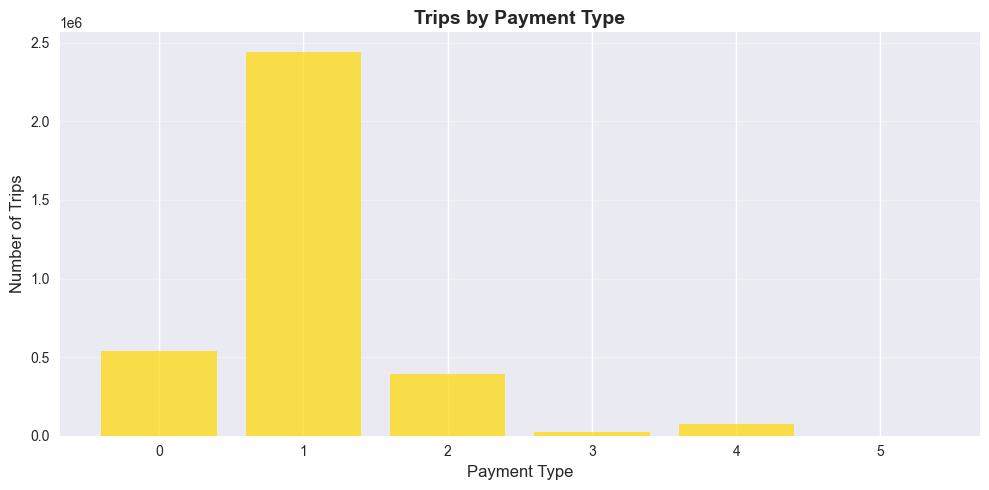


Payment Type Breakdown:
Type 0         :    540,149 trips (15.54%)
Credit Card    :  2,444,393 trips (70.34%)
Cash           :    390,429 trips (11.23%)
No Charge      :     23,773 trips ( 0.68%)
Dispute        :     76,481 trips ( 2.20%)
Unknown        :          1 trips ( 0.00%)


In [18]:
# Payment type analysis
# Common payment types: 1 = Credit card, 2 = Cash, 3 = No charge, 4 = Dispute, 5 = Unknown, 6 = Voided trip
payment_counts = df['payment_type'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(payment_counts.index.astype(str), payment_counts.values, color='gold', alpha=0.7)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Trips by Payment Type', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print payment type breakdown
print("\nPayment Type Breakdown:")
print("=" * 40)
payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided Trip'}
for ptype, count in payment_counts.items():
    label = payment_labels.get(ptype, f'Type {ptype}')
    percentage = (count / len(df)) * 100
    print(f"{label:15s}: {count:>10,} trips ({percentage:5.2f}%)")

### 11.1 Tip Analysis

Let's analyze tipping behavior - how often do people tip and how much?

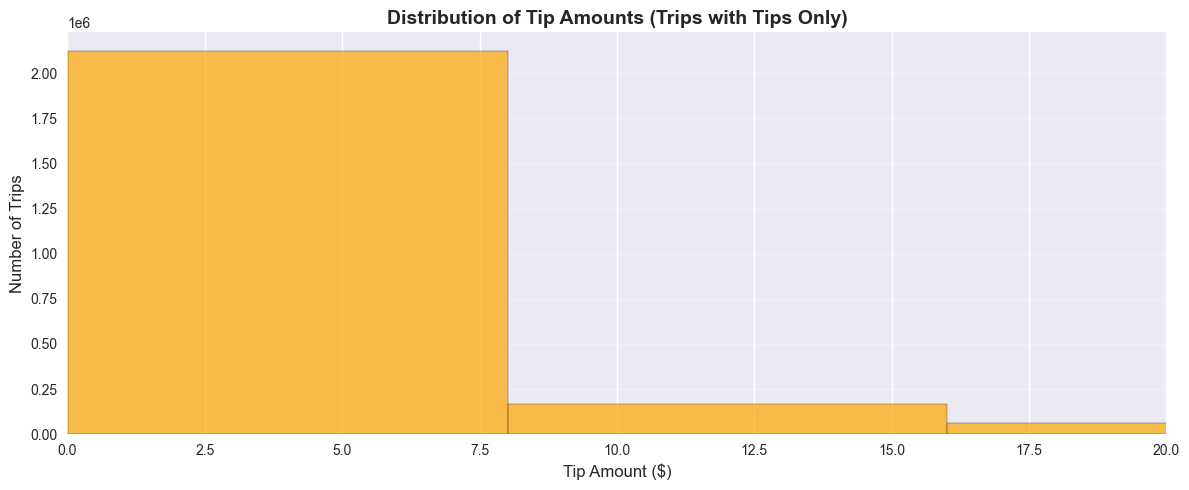


Tip Statistics:
Trips with tips:        2,357,094 (67.83%)
Trips without tips:     1,118,132 (32.17%)

Average tip (when given): $4.36
Median tip (when given): $3.30
Max tip:                $400.00


In [19]:
# Tip analysis - only for trips with tips
trips_with_tips = df[df['tip_amount'] > 0]

# Create histogram of tip amounts
plt.figure(figsize=(12, 5))
plt.hist(trips_with_tips['tip_amount'], bins=50, color='orange', alpha=0.7, edgecolor='black')
plt.xlabel('Tip Amount ($)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Distribution of Tip Amounts (Trips with Tips Only)', fontsize=14, fontweight='bold')
plt.xlim(0, 20)  # Focus on tips up to $20 for better visualization
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print tip statistics
print("\nTip Statistics:")
print("=" * 40)
print(f"Trips with tips:        {len(trips_with_tips):,} ({(len(trips_with_tips)/len(df)*100):.2f}%)")
print(f"Trips without tips:     {len(df) - len(trips_with_tips):,} ({((len(df)-len(trips_with_tips))/len(df)*100):.2f}%)")
print(f"\nAverage tip (when given): ${trips_with_tips['tip_amount'].mean():.2f}")
print(f"Median tip (when given): ${trips_with_tips['tip_amount'].median():.2f}")
print(f"Max tip:                ${trips_with_tips['tip_amount'].max():.2f}")

## 12. Categorical Variables Analysis

Let's examine other categorical variables like VendorID, RatecodeID, and store_and_fwd_flag.

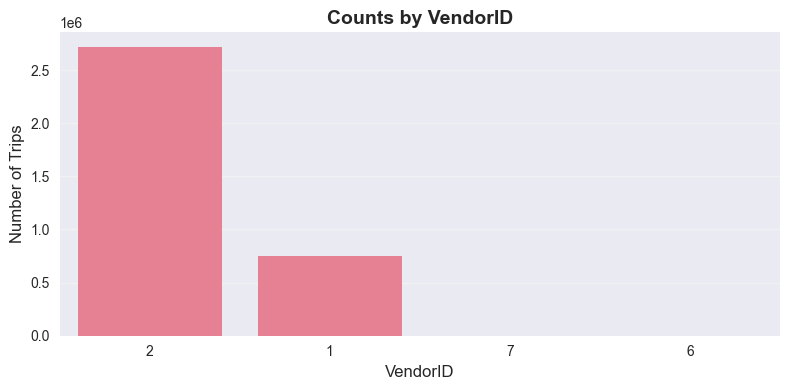

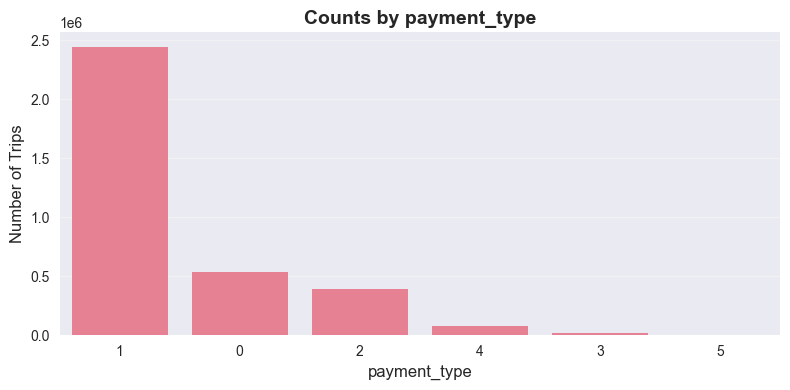

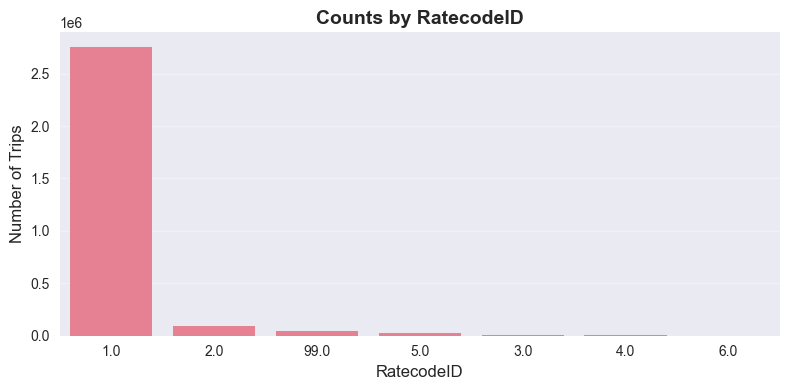

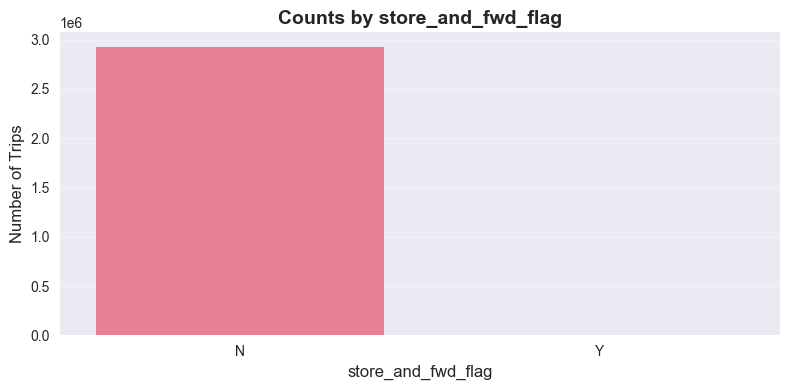

In [20]:
# Analyze categorical variables
cat_cols = ["VendorID", "payment_type", "RatecodeID", "store_and_fwd_flag"]
for col in [c for c in cat_cols if c in df.columns]:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Counts by {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Trips', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13. Relationships Between Variables

Let's explore how different variables relate to each other. For example:
- Does trip distance affect the fare amount?
- Is there a relationship between trip duration and distance?
- How does tip amount relate to total fare?

### 13.1 Correlation Heatmap

A correlation heatmap shows how strongly different numerical variables are related to each other.

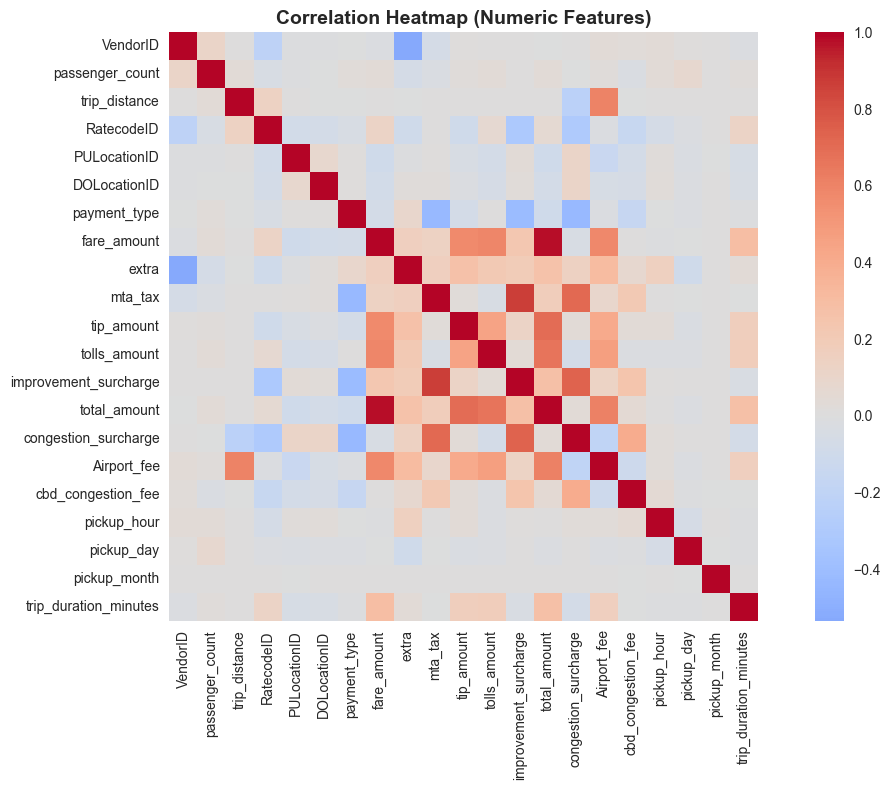

In [22]:
# Prepare data for correlation analysis
plot_df = df.sample(200000, random_state=42) if len(df) > 300000 else df.copy()

# Clean numeric columns
for col in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    if col in plot_df.columns:
        plot_df = plot_df[pd.to_numeric(plot_df[col], errors="coerce").notna()]
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    c for c in ["trip_distance","fare_amount","tip_amount","total_amount"] if c in plot_df.columns
])

# Correlation matrix for numeric features
num_cols = plot_df.select_dtypes(include=[np.number]).columns
corr = plot_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 13.2 Scatter Plots: Key Relationships

Scatter plots help us visualize relationships between pairs of variables. All plots below filter out negative values for clearer visualization.

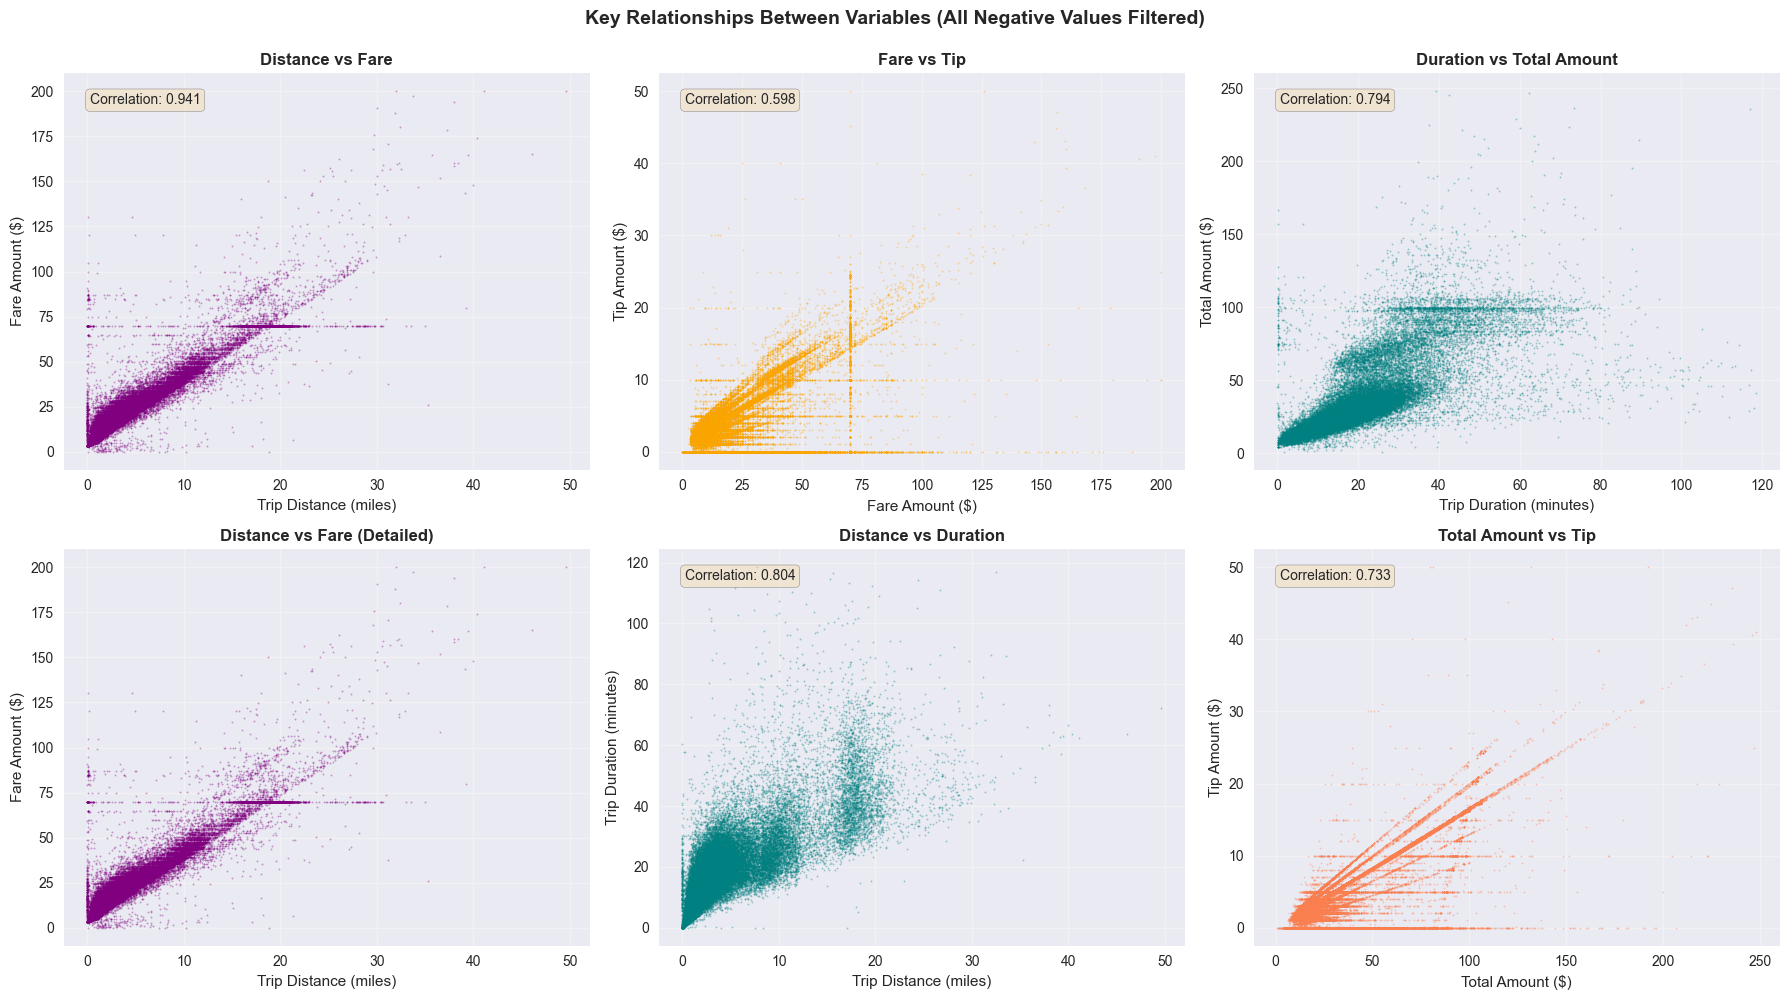


CORRELATION SUMMARY
Trip Distance vs Fare Amount:        0.941
Fare Amount vs Tip Amount:           0.598
Trip Duration vs Total Amount:       0.794
Trip Distance vs Trip Duration:      0.804
Total Amount vs Tip Amount:          0.733

(Values closer to 1.0 mean stronger positive relationship)

Data points used: 93,555 trips (negative values filtered)


In [30]:
# Create a sample for faster visualization (use 100,000 random trips)
sample_size = min(100000, len(df))
sample_trips = df.sample(n=sample_size, random_state=42)

# Calculate trip duration if not already present
if 'trip_duration_minutes' not in sample_trips.columns:
    sample_trips['trip_duration_minutes'] = (
        (sample_trips['tpep_dropoff_datetime'] - sample_trips['tpep_pickup_datetime']).dt.total_seconds() / 60
    )

# Filter out ALL negative values and unrealistic values for cleaner visualization
clean_data = sample_trips[
    (sample_trips['trip_distance'] > 0) & 
    (sample_trips['trip_distance'] <= 50) &
    (sample_trips['fare_amount'] > 0) & 
    (sample_trips['fare_amount'] <= 200) &
    (sample_trips['tip_amount'] >= 0) &
    (sample_trips['tip_amount'] <= 50) &
    (sample_trips['total_amount'] > 0) &
    (sample_trips['total_amount'] <= 250) &
    (sample_trips['trip_duration_minutes'] > 0) &
    (sample_trips['trip_duration_minutes'] <= 120)
]

# Create all relationship plots in a single figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distance vs Fare
axes[0, 0].scatter(clean_data['trip_distance'], clean_data['fare_amount'], 
                   alpha=0.3, s=1, color='purple')
axes[0, 0].set_xlabel('Trip Distance (miles)', fontsize=11)
axes[0, 0].set_ylabel('Fare Amount ($)', fontsize=11)
axes[0, 0].set_title('Distance vs Fare', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
corr1 = clean_data['trip_distance'].corr(clean_data['fare_amount'])
axes[0, 0].text(0.05, 0.95, f'Correlation: {corr1:.3f}', 
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Fare vs Tip
axes[0, 1].scatter(clean_data['fare_amount'], clean_data['tip_amount'], 
                   alpha=0.3, s=1, color='orange')
axes[0, 1].set_xlabel('Fare Amount ($)', fontsize=11)
axes[0, 1].set_ylabel('Tip Amount ($)', fontsize=11)
axes[0, 1].set_title('Fare vs Tip', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
corr2 = clean_data['fare_amount'].corr(clean_data['tip_amount'])
axes[0, 1].text(0.05, 0.95, f'Correlation: {corr2:.3f}', 
                transform=axes[0, 1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Duration vs Total Amount
axes[0, 2].scatter(clean_data['trip_duration_minutes'], clean_data['total_amount'], 
                   alpha=0.3, s=1, color='teal')
axes[0, 2].set_xlabel('Trip Duration (minutes)', fontsize=11)
axes[0, 2].set_ylabel('Total Amount ($)', fontsize=11)
axes[0, 2].set_title('Duration vs Total Amount', fontsize=12, fontweight='bold')
axes[0, 2].grid(alpha=0.3)
corr3 = clean_data['trip_duration_minutes'].corr(clean_data['total_amount'])
axes[0, 2].text(0.05, 0.95, f'Correlation: {corr3:.3f}', 
                transform=axes[0, 2].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Distance vs Fare (Detailed - larger view)
axes[1, 0].scatter(clean_data['trip_distance'], clean_data['fare_amount'], 
                   alpha=0.3, s=1, color='purple')
axes[1, 0].set_xlabel('Trip Distance (miles)', fontsize=11)
axes[1, 0].set_ylabel('Fare Amount ($)', fontsize=11)
axes[1, 0].set_title('Distance vs Fare (Detailed)', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 5. Distance vs Duration
axes[1, 1].scatter(clean_data['trip_distance'], clean_data['trip_duration_minutes'], 
                   alpha=0.3, s=1, color='teal')
axes[1, 1].set_xlabel('Trip Distance (miles)', fontsize=11)
axes[1, 1].set_ylabel('Trip Duration (minutes)', fontsize=11)
axes[1, 1].set_title('Distance vs Duration', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
corr4 = clean_data['trip_distance'].corr(clean_data['trip_duration_minutes'])
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr4:.3f}', 
                transform=axes[1, 1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 6. Tip vs Total Amount
axes[1, 2].scatter(clean_data['total_amount'], clean_data['tip_amount'], 
                   alpha=0.3, s=1, color='coral')
axes[1, 2].set_xlabel('Total Amount ($)', fontsize=11)
axes[1, 2].set_ylabel('Tip Amount ($)', fontsize=11)
axes[1, 2].set_title('Total Amount vs Tip', fontsize=12, fontweight='bold')
axes[1, 2].grid(alpha=0.3)
corr5 = clean_data['total_amount'].corr(clean_data['tip_amount'])
axes[1, 2].text(0.05, 0.95, f'Correlation: {corr5:.3f}', 
                transform=axes[1, 2].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Key Relationships Between Variables (All Negative Values Filtered)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary correlations
print("\n" + "="*60)
print("CORRELATION SUMMARY")
print("="*60)
print(f"Trip Distance vs Fare Amount:        {corr1:.3f}")
print(f"Fare Amount vs Tip Amount:           {corr2:.3f}")
print(f"Trip Duration vs Total Amount:       {corr3:.3f}")
print(f"Trip Distance vs Trip Duration:      {corr4:.3f}")
print(f"Total Amount vs Tip Amount:          {corr5:.3f}")
print("\n(Values closer to 1.0 mean stronger positive relationship)")
print(f"\nData points used: {len(clean_data):,} trips (negative values filtered)")

## 14. Cost Breakdown Analysis

Let's see how the total fare is made up of different components (base fare, tips, taxes, surcharges, etc.). This helps understand pricing structure.

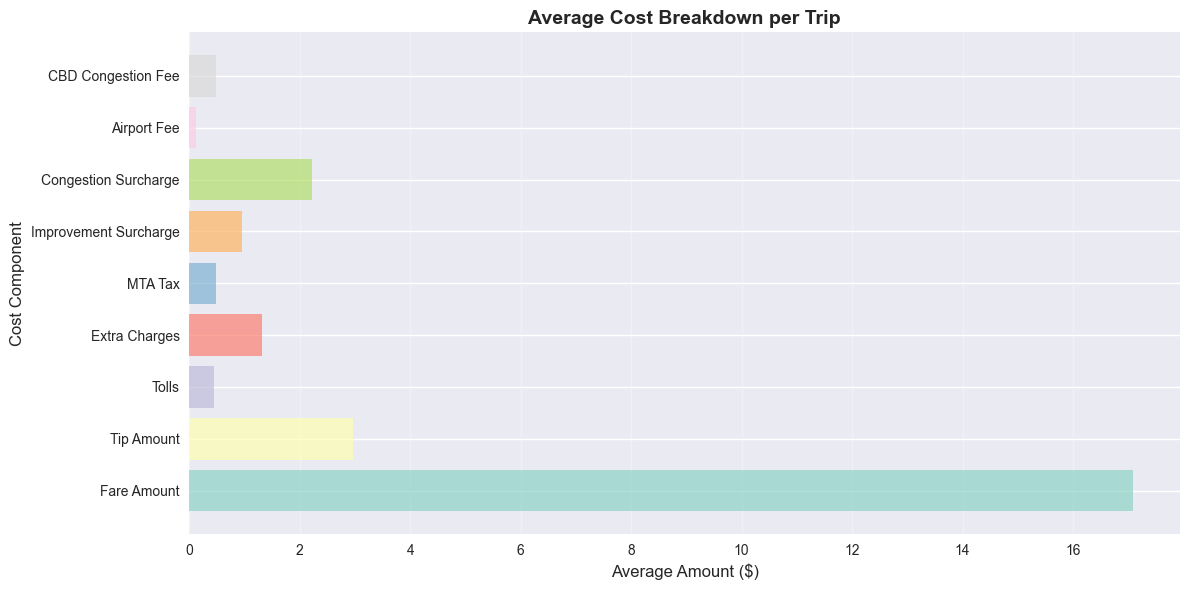


Average Cost Breakdown per Trip:
Fare Amount              : $   17.08
Tip Amount               : $    2.96
Tolls                    : $    0.45
Extra Charges            : $    1.32
MTA Tax                  : $    0.48
Improvement Surcharge    : $    0.95
Congestion Surcharge     : $    2.23
Airport Fee              : $    0.12
CBD Congestion Fee       : $    0.48

Total Amount             : $   25.61


In [25]:
# Calculate average amounts for each cost component
cost_components = {
    'Fare Amount': df['fare_amount'].mean(),
    'Tip Amount': df['tip_amount'].mean(),
    'Tolls': df['tolls_amount'].mean(),
    'Extra Charges': df['extra'].mean(),
    'MTA Tax': df['mta_tax'].mean(),
    'Improvement Surcharge': df['improvement_surcharge'].mean(),
    'Congestion Surcharge': df['congestion_surcharge'].mean(),
    'Airport Fee': df['Airport_fee'].mean(),
    'CBD Congestion Fee': df['cbd_congestion_fee'].mean()
}

# Create bar chart
plt.figure(figsize=(12, 6))
components = list(cost_components.keys())
amounts = list(cost_components.values())
colors = plt.cm.Set3(range(len(components)))

plt.barh(components, amounts, color=colors, alpha=0.7)
plt.xlabel('Average Amount ($)', fontsize=12)
plt.ylabel('Cost Component', fontsize=12)
plt.title('Average Cost Breakdown per Trip', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print breakdown
print("\nAverage Cost Breakdown per Trip:")
print("=" * 50)
for component, amount in cost_components.items():
    print(f"{component:25s}: ${amount:>8.2f}")
print(f"\n{'Total Amount':25s}: ${df['total_amount'].mean():>8.2f}")

## 15. Summary and Key Insights

This comprehensive analysis revealed several interesting patterns and insights about NYC taxi trips in January 2025.

### Key Findings:

1. **Dataset Overview**
   - Total of 3,475,226 taxi trips in January 2025
   - 20 columns of information per trip
   - Some missing values in passenger_count, RatecodeID, and related fields (~15.5%)

2. **Time Patterns**
   - **Peak hours**: Most trips occur during evening rush hours (5-7 PM)
   - **Day patterns**: Weekdays (especially Wednesday-Thursday) tend to have more trips than weekends
   - **Peak demand**: Evening commute hours show highest activity

3. **Trip Characteristics**
   - **Distance**: Average trip distance is approximately 5.86 miles
   - **Duration**: Most trips are relatively short (median ~12 minutes, mean ~15 minutes)
   - **Passengers**: Vast majority of trips (67%) have 1 passenger

4. **Locations**
   - Certain locations (161, 237, 236, 132, 230) are much more popular than others
   - Top pickup and dropoff locations show similar patterns, suggesting common routes

5. **Payment Behavior**
   - **Credit cards** are the most common payment method (70% of trips)
   - **Cash** accounts for about 11% of trips
   - **Tipping**: About 68% of trips include tips, with average tip of $4.36 when given

6. **Relationships**
   - **Strong correlation** between trip distance and fare amount (0.941)
   - **Strong correlation** between trip distance and duration (0.803)
   - These relationships are expected and validate data quality

7. **Cost Structure**
   - Average total trip cost: $25.61
   - Base fare: $17.08 (largest component)
   - Tips: $2.96 average
   - Various surcharges and fees make up the remainder

### Potential Applications:

These insights can help with:
- **Resource allocation**: Scheduling more taxis during peak hours
- **Understanding customer behavior**: Payment preferences and tipping patterns
- **Identifying high-demand areas**: Location-based optimization
- **Pricing strategies**: Understanding cost components
- **Demand forecasting**: Time-based patterns for predictive models